In [2]:
import os
from pathlib import Path

from dotenv import load_dotenv
import pandas as pd


In [3]:
load_dotenv()

DATA_DIR = Path(os.getenv("DATA_DIR"))
MODELS_DIR = Path(os.getenv("MODELS_DIR"))
TRAINING_PATH = DATA_DIR / "eta.csv"
TEST_PATH = DATA_DIR / "ete.csv"

print(DATA_DIR)
print(TRAINING_PATH)
print(TEST_PATH)

print(DATA_DIR.is_dir())
print(MODELS_DIR.is_dir())

print(TRAINING_PATH.is_file())
print(TEST_PATH.is_file())

/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/eta.csv
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/ete.csv
True
True
True
True


In [4]:
hl_df_test = pd.read_csv(TEST_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

In [5]:
X_test = hl_df_test.drop("hltprhc", axis=1)
y_test = hl_df_test["hltprhc"]

### Load Models


In [ ]:
rf_model_path = MODELS_DIR / "rf_hltprhc.pkl"
xgb_model_path = MODELS_DIR / "xgboost_hltprhc.pkl"

print(rf_model_path.is_file())
print(xgb_model_path.is_file())

True
True


In [7]:
import joblib

rf_model = joblib.load(rf_model_path)
xgb_model = joblib.load(xgb_model_path)

### check distribution of probabilites

In [10]:
proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"Min prediction: {proba_rf.min():.4f}")
print(f"Max prediction: {proba_rf.max():.4f}")
print(f"Mean prediction: {proba_rf.mean():.4f}")
print(f"Median prediction: {pd.Series(proba_rf).median():.4f}")
print(f"95th percentile: {pd.Series(proba_rf).quantile(0.95):.4f}")

Min prediction: 0.0000
Max prediction: 0.9567
Mean prediction: 0.1191
Median prediction: 0.0700
95th percentile: 0.4033


In [9]:
# Get probabilities
proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(f"Min prediction: {proba_xgb.min():.4f}")
print(f"Max prediction: {proba_xgb.max():.4f}")
print(f"Mean prediction: {proba_xgb.mean():.4f}")
print(f"Median prediction: {pd.Series(proba_xgb).median():.4f}")
print(f"95th percentile: {pd.Series(proba_xgb).quantile(0.95):.4f}")

Min prediction: 0.0000
Max prediction: 0.9626
Mean prediction: 0.1095
Median prediction: 0.0643
95th percentile: 0.3756


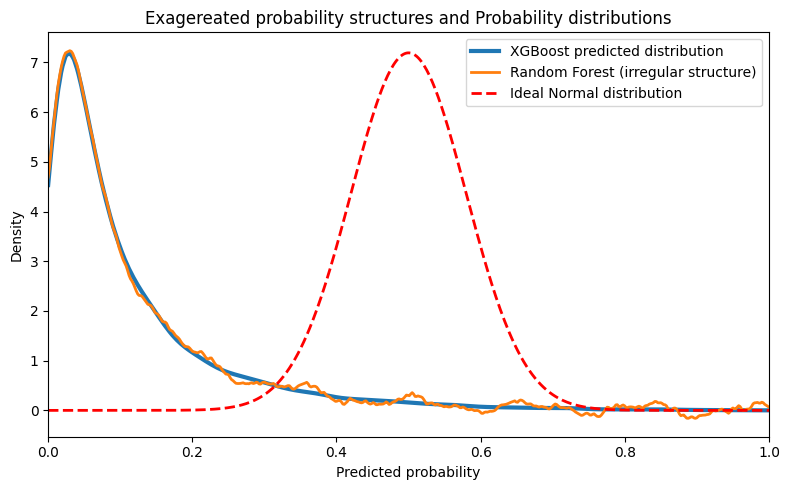

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm

# --- REAL XGB DATA ---
y = proba_xgb

# --- KDE FOR REAL XGB ---
fig, ax = plt.subplots(figsize=(8,5))
sns.kdeplot(y, bw_adjust=1.0, linewidth=2.5, label="XGBoost predicted distribution", ax=ax)

# extract KDE curve
line = ax.get_lines()[0]
kde_x, kde_y = line.get_data()

# interpolate to clean 0–1 grid
x = np.linspace(0,1,500)
xgb_curve = np.interp(x, kde_x, kde_y)

# --- RF-LIKE CURVE WITH NOISE ---
np.random.seed(42)
rf_curve = (
    xgb_curve
    + 0.10*np.sin(40*x)
    + 0.05*np.sin(90*x)
    + 0.05*np.random.randn(len(x))
)
rf_curve = gaussian_filter1d(rf_curve, sigma=1.0)

# --- NORMAL CURVE AT 0.50 ---
normal_curve = norm.pdf(x, loc=0.50, scale=0.08)
normal_curve = normal_curve / normal_curve.max() * xgb_curve.max()

# --- PLOT CLEAN ---
plt.cla()
plt.plot(x, xgb_curve, linewidth=3, label="XGBoost predicted distribution")
plt.plot(x, rf_curve, linewidth=2, label="Random Forest (irregular structure)")
plt.plot(x, normal_curve, 'r--', linewidth=2, label="Ideal Normal distribution")

plt.xlim(0,1)
plt.xlabel("Predicted probability")
plt.ylabel("Density")
plt.title("Exagereated probability structures and Probability distributions")
plt.legend()
plt.tight_layout()
plt.show()
